In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

DATA_RAW  = os.path.join('..', 'data', 'raw')
DATA_PROC = os.path.join('..', 'data', 'processed')
os.makedirs(DATA_PROC, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Cargamos los CSV que necesitamos
ventas_lin = pd.read_csv(os.path.join(DATA_RAW, 'ventas_lineas.csv'),
                         parse_dates=['fecha_venta'])
calendario = pd.read_csv(os.path.join(DATA_RAW, 'calendario_ciudad.csv'),
                         parse_dates=['fecha'])
inversion  = pd.read_csv(os.path.join(DATA_RAW, 'inversion_medios_semanal.csv'),
                         parse_dates=['semana_inicio', 'semana_fin'])
trafico    = pd.read_csv(os.path.join(DATA_RAW, 'trafico_tienda_web_diario.csv'),
                         parse_dates=['fecha'])

print("âœ“ Datos cargados")

âœ“ Datos cargados


In [25]:
# Agrupamos ventas_lineas por dÃ­a â€” ignoramos ciudad e id_pedido
# Esta es la variable dependiente Yt del modelo MMM
ventas_diarias = (
    ventas_lin
    .groupby('fecha_venta')
    .agg(
        venta_neta_eur  = ('venta_neta_sin_iva_eur', 'sum'),
        unidades        = ('cantidad_unidades',       'sum'),
        num_lineas      = ('id_linea',                'count')
    )
    .reset_index()
    .rename(columns={'fecha_venta': 'fecha'})
    .sort_values('fecha')
)

print(f"Rango temporal: {ventas_diarias['fecha'].min()} â†’ {ventas_diarias['fecha'].max()}")
print(f"DÃ­as totales:   {len(ventas_diarias)}")
print(f"\nVenta neta diaria media: {ventas_diarias['venta_neta_eur'].mean():,.0f} â‚¬")
print(f"Venta neta diaria total: {ventas_diarias['venta_neta_eur'].sum():,.0f} â‚¬")
display(ventas_diarias.head())

Rango temporal: 2020-01-01 00:00:00 â†’ 2024-12-31 00:00:00
DÃ­as totales:   1827

Venta neta diaria media: 420,411 â‚¬
Venta neta diaria total: 768,090,254 â‚¬


,fecha,venta_neta_eur,unidades,num_lineas
0,2020-01-01,252761.71,6635,2624
1,2020-01-02,262162.63,6841,2745
2,2020-01-03,255724.04,6624,2674
3,2020-01-04,258620.66,6694,2677
4,2020-01-05,260597.72,6739,2704


In [26]:
# Ignoramos ciudad â€” agregamos flags a nivel nacional por fecha
# Para variables numÃ©ricas tomamos la media entre ciudades
# Para flags binarios tomamos el mÃ¡ximo (si en alguna ciudad hay festivo, se considera festivo)

cal_nacional = (
    calendario
    .groupby('fecha')
    .agg(
        fin_de_semana          = ('fin_de_semana',          'max'),
        payday_flag            = ('payday_flag',            'max'),
        rebajas_flag           = ('rebajas_flag',           'max'),
        black_friday_flag      = ('black_friday_flag',      'max'),
        navidad_flag           = ('navidad_flag',           'max'),
        semana_santa_flag      = ('semana_santa_flag',      'max'),
        vacaciones_flag        = ('vacaciones_escolares_flag','max'),
        festivo_local_flag     = ('festivo_local_flag',     'max'),
        temperatura_media_c    = ('temperatura_media_c',    'mean'),
        lluvia_indice          = ('lluvia_indice',          'mean'),
        turismo_indice         = ('turismo_indice',         'mean'),
        incidencia_ecommerce   = ('incidencia_ecommerce_flag','max')
    )
    .reset_index()
)

# AÃ±adimos variables de tendencia temporal
cal_nacional = cal_nacional.sort_values('fecha').reset_index(drop=True)
cal_nacional['tendencia'] = np.arange(len(cal_nacional))  # Ã­ndice lineal de tiempo

# Indicadores de aÃ±o para capturar los saltos escalonados que vimos en la exploraciÃ³n
cal_nacional['anio'] = cal_nacional['fecha'].dt.year
for yr in [2021, 2022, 2023, 2024]:
    cal_nacional[f'dummy_anio_{yr}'] = (cal_nacional['anio'] >= yr).astype(int)

print(f"Calendario nacional: {cal_nacional.shape}")
display(cal_nacional.head(3))

Calendario nacional: (1827, 19)


,fecha,fin_de_semana,payday_flag,rebajas_flag,black_friday_flag,navidad_flag,semana_santa_flag,vacaciones_flag,festivo_local_flag,temperatura_media_c,lluvia_indice,turismo_indice,incidencia_ecommerce,tendencia,anio,dummy_anio_2021,dummy_anio_2022,dummy_anio_2023,dummy_anio_2024
0,2020-01-01,0,1,0,0,0,0,0,0,9.67,61.18,25.48,0,0,2020,0,0,0,0
1,2020-01-02,0,1,0,0,0,0,0,0,8.90,58.93,31.84,0,1,2020,0,0,0,0
2,2020-01-03,0,1,0,0,0,0,0,0,7.80,54.39,31.89,0,2,2020,0,0,0,0


In [27]:
trafico_nacional = (
    trafico
    .groupby('fecha')
    .agg(
        sesiones_web       = ('sesiones_web',    'sum'),
        pedidos_online     = ('pedidos_online',  'sum'),
        visitas_tienda     = ('visitas_tienda',  'sum'),
        conv_web_pct       = ('tasa_conversion_web_pct', 'mean')
    )
    .reset_index()
)

print(f"TrÃ¡fico nacional: {trafico_nacional.shape}")
display(trafico_nacional.head(3))

TrÃ¡fico nacional: (1827, 5)


,fecha,sesiones_web,pedidos_online,visitas_tienda,conv_web_pct
0,2020-01-01,1925,53.0,338,0.03685
1,2020-01-02,1951,49.0,275,0.03691
2,2020-01-03,1834,40.0,316,0.03345


In [28]:
# Calculamos la inversiÃ³n total por semana y canal (ignoramos ciudad)
inv_canal = (
    inversion
    .groupby(['semana_inicio', 'semana_fin', 'canal_medio'])['inversion_eur']
    .sum()
    .reset_index()
)

# Pivot: cada canal se convierte en columna
inv_pivot = inv_canal.pivot_table(
    index=['semana_inicio', 'semana_fin'],
    columns='canal_medio',
    values='inversion_eur',
    aggfunc='sum'
).reset_index()

# Limpiamos nombres de columnas
inv_pivot.columns.name = None
canales = [c for c in inv_pivot.columns if c not in ['semana_inicio', 'semana_fin']]
canales_col = [f'inv_{c.lower().replace(" ", "_")}' for c in canales]
rename_map = {c: f'inv_{c.lower().replace(" ", "_")}' for c in canales}
inv_pivot = inv_pivot.rename(columns=rename_map)
inv_pivot = inv_pivot.fillna(0)

print("Canales de inversiÃ³n disponibles:")
for c in canales_col:
    print(f"  {c}")

# Expandimos semanas a dÃ­as (dividimos inversiÃ³n semanal entre 7)
dias_list = []
for _, row in inv_pivot.iterrows():
    fechas_semana = pd.date_range(row['semana_inicio'], row['semana_fin'], freq='D')
    for fecha in fechas_semana:
        fila = {'fecha': fecha}
        for col in canales_col:
            fila[col] = row[col] / 7
        dias_list.append(fila)

inv_diaria = pd.DataFrame(dias_list)
inv_diaria = inv_diaria.groupby('fecha')[canales_col].sum().reset_index()

print(f"\nInversiÃ³n diaria: {inv_diaria.shape}")
display(inv_diaria.head(3))

Canales de inversiÃ³n disponibles:
  inv_display
  inv_email_crm
  inv_exterior
  inv_paid_search
  inv_prensa
  inv_radio_local
  inv_social_paid
  inv_video_online

InversiÃ³n diaria: (1827, 9)


,fecha,inv_display,inv_email_crm,inv_exterior,inv_paid_search,inv_prensa,inv_radio_local,inv_social_paid,inv_video_online
0,2020-01-06,1749.975714,1061.478571,3124.672857,4608.005714,1795.241429,2511.171429,3837.727143,3866.552857
1,2020-01-07,1749.975714,1061.478571,3124.672857,4608.005714,1795.241429,2511.171429,3837.727143,3866.552857
2,2020-01-08,1749.975714,1061.478571,3124.672857,4608.005714,1795.241429,2511.171429,3837.727143,3866.552857


In [29]:
# ParÃ¡metros de Adstock por canal (tasas de decaimiento Î±)
# Medios con mayor persistencia de marca tienen Î± mÃ¡s alto
adstock_params = {
    'inv_display':      {'lag': 1, 'alpha': 0.5},
    'inv_email_crm':    {'lag': 0, 'alpha': 0.2},
    'inv_exterior':     {'lag': 2, 'alpha': 0.6},
    'inv_paid_search':  {'lag': 0, 'alpha': 0.3},
    'inv_prensa':       {'lag': 1, 'alpha': 0.4},
    'inv_radio_local':  {'lag': 1, 'alpha': 0.5},
    'inv_social_paid':  {'lag': 1, 'alpha': 0.4},
    'inv_video_online': {'lag': 2, 'alpha': 0.6},
}

def aplicar_lag_adstock(serie, lag, alpha):
    """
    EcuaciÃ³n (1): X't,m = X(t-L),m   â†’ desplazamiento temporal
    EcuaciÃ³n (2): At,m = X't,m + Î± Â· A(t-1),m â†’ memoria de marca
    """
    # Lag
    serie_lag = serie.shift(lag).fillna(0)
    # Adstock recursivo
    adstock = np.zeros(len(serie_lag))
    for t in range(len(serie_lag)):
        if t == 0:
            adstock[t] = serie_lag.iloc[t]
        else:
            adstock[t] = serie_lag.iloc[t] + alpha * adstock[t - 1]
    return adstock

inv_adstock = inv_diaria.copy()
for canal, params in adstock_params.items():
    if canal in inv_adstock.columns:
        col_nueva = canal.replace('inv_', 'ads_')
        inv_adstock[col_nueva] = aplicar_lag_adstock(
            inv_adstock[canal], params['lag'], params['alpha']
        )
        print(f"âœ“ Adstock aplicado: {canal} â†’ {col_nueva}  (lag={params['lag']}, Î±={params['alpha']})")

# Columnas adstock generadas
cols_adstock = [c for c in inv_adstock.columns if c.startswith('ads_')]
print(f"\nColumnas adstock: {cols_adstock}")

âœ“ Adstock aplicado: inv_display â†’ ads_display  (lag=1, Î±=0.5)
âœ“ Adstock aplicado: inv_email_crm â†’ ads_email_crm  (lag=0, Î±=0.2)
âœ“ Adstock aplicado: inv_exterior â†’ ads_exterior  (lag=2, Î±=0.6)
âœ“ Adstock aplicado: inv_paid_search â†’ ads_paid_search  (lag=0, Î±=0.3)
âœ“ Adstock aplicado: inv_prensa â†’ ads_prensa  (lag=1, Î±=0.4)
âœ“ Adstock aplicado: inv_radio_local â†’ ads_radio_local  (lag=1, Î±=0.5)
âœ“ Adstock aplicado: inv_social_paid â†’ ads_social_paid  (lag=1, Î±=0.4)
âœ“ Adstock aplicado: inv_video_online â†’ ads_video_online  (lag=2, Î±=0.6)

Columnas adstock: ['ads_display', 'ads_email_crm', 'ads_exterior', 'ads_paid_search', 'ads_prensa', 'ads_radio_local', 'ads_social_paid', 'ads_video_online']


In [30]:
# Unimos todo: ventas + calendario + trÃ¡fico + inversiÃ³n adstock
df = ventas_diarias.copy()
df = df.merge(cal_nacional,    on='fecha', how='left')
df = df.merge(trafico_nacional, on='fecha', how='left')
df = df.merge(inv_adstock[['fecha'] + cols_adstock], on='fecha', how='left')

# Verificamos
print(f"Dataset maestro: {df.shape}")
print(f"Nulos tras merge: {df.isnull().sum().sum()}")
print(f"Rango: {df['fecha'].min()} â†’ {df['fecha'].max()}")
display(df.head(3))

Dataset maestro: (1827, 34)
Nulos tras merge: 40
Rango: 2020-01-01 00:00:00 â†’ 2024-12-31 00:00:00


,fecha,venta_neta_eur,unidades,num_lineas,fin_de_semana,payday_flag,rebajas_flag,black_friday_flag,navidad_flag,semana_santa_flag,...,visitas_tienda,conv_web_pct,ads_display,ads_email_crm,ads_exterior,ads_paid_search,ads_prensa,ads_radio_local,ads_social_paid,ads_video_online
0,2020-01-01,252761.71,6635,2624,0,1,0,0,0,0,...,338,0.03685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,262162.63,6841,2745,0,1,0,0,0,0,...,275,0.03691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,255724.04,6624,2674,0,1,0,0,0,0,...,316,0.03345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Los nulos vienen de los primeros dÃ­as donde no hay datos de inversiÃ³n todavÃ­a
# Para esos dÃ­as asumimos inversiÃ³n 0 (antes de que empezara la primera semana)
print("Nulos por columna antes de imputar:")
print(df[cols_adstock].isnull().sum())

df[cols_adstock] = df[cols_adstock].fillna(0)

# Verificamos
print(f"\nNulos tras imputar: {df.isnull().sum().sum()}")

# Sobreescribimos el CSV guardado
df.to_csv(os.path.join(DATA_PROC, 'dataset_maestro.csv'), index=False)
print("âœ“ Dataset maestro actualizado sin nulos")

Nulos por columna antes de imputar:
ads_display         5
ads_email_crm       5
ads_exterior        5
ads_paid_search     5
ads_prensa          5
ads_radio_local     5
ads_social_paid     5
ads_video_online    5
dtype: int64

Nulos tras imputar: 0
âœ“ Dataset maestro actualizado sin nulos


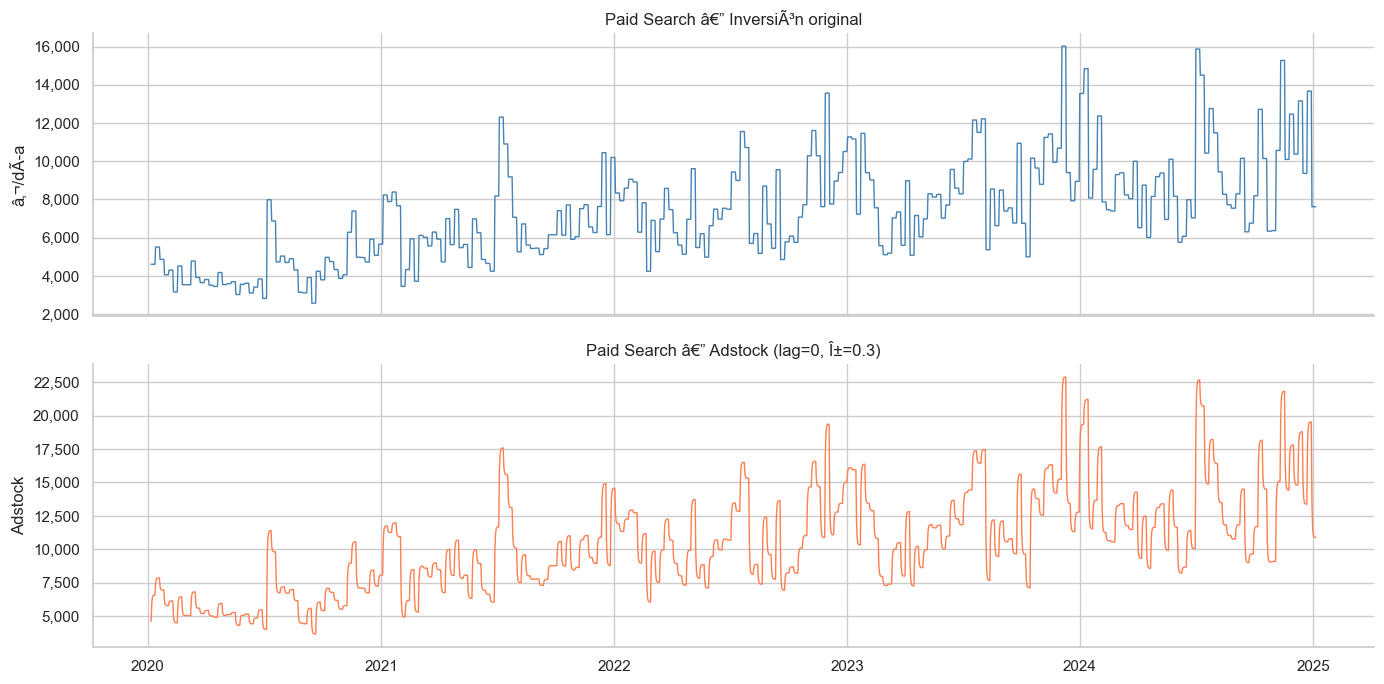

In [32]:
# Comparamos inversiÃ³n original vs adstock en un canal para verificar que funciona
canal_ejemplo = 'paid_search'

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(inv_adstock['fecha'], inv_adstock[f'inv_{canal_ejemplo}'],
             color='steelblue', linewidth=1, label='InversiÃ³n original')
axes[0].set_title(f'Paid Search â€” InversiÃ³n original')
axes[0].set_ylabel('â‚¬/dÃ­a')

axes[1].plot(inv_adstock['fecha'], inv_adstock[f'ads_{canal_ejemplo}'],
             color='coral', linewidth=1, label='Adstock transformado')
axes[1].set_title(f'Paid Search â€” Adstock (lag=0, Î±=0.3)')
axes[1].set_ylabel('Adstock')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [33]:
output_path = os.path.join(DATA_PROC, 'dataset_maestro.csv')
df.to_csv(output_path, index=False)
print(f"âœ“ Dataset maestro guardado en: {output_path}")
print(f"  Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
print(f"\nColumnas finales:")
for col in df.columns:
    print(f"  {col}")

âœ“ Dataset maestro guardado en: ..\data\processed\dataset_maestro.csv
  Filas: 1,827  |  Columnas: 34

Columnas finales:
  fecha
  venta_neta_eur
  unidades
  num_lineas
  fin_de_semana
  payday_flag
  rebajas_flag
  black_friday_flag
  navidad_flag
  semana_santa_flag
  vacaciones_flag
  festivo_local_flag
  temperatura_media_c
  lluvia_indice
  turismo_indice
  incidencia_ecommerce
  tendencia
  anio
  dummy_anio_2021
  dummy_anio_2022
  dummy_anio_2023
  dummy_anio_2024
  sesiones_web
  pedidos_online
  visitas_tienda
  conv_web_pct
  ads_display
  ads_email_crm
  ads_exterior
  ads_paid_search
  ads_prensa
  ads_radio_local
  ads_social_paid
  ads_video_online


In [34]:
import pandas as pd
import numpy as np
import os

DATA_PROC = os.path.join('..', 'data', 'processed')

# Cargamos el dataset maestro diario
df = pd.read_csv(os.path.join(DATA_PROC, 'dataset_maestro.csv'),
                 parse_dates=['fecha'])

# Convertimos a semanal (semana empieza el lunes)
df['semana'] = df['fecha'].dt.to_period('W-MON').dt.start_time

vars_suma = ['venta_neta_eur', 'unidades', 'num_lineas',
             'sesiones_web', 'pedidos_online', 'visitas_tienda',
             'ads_video_online', 'ads_display', 'ads_email_crm',
             'ads_prensa', 'ads_exterior', 'ads_radio_local',
             'ads_social_paid', 'ads_paid_search']

vars_media = ['fin_de_semana', 'payday_flag', 'rebajas_flag',
              'black_friday_flag', 'navidad_flag', 'semana_santa_flag',
              'vacaciones_flag', 'festivo_local_flag',
              'temperatura_media_c', 'lluvia_indice', 'turismo_indice',
              'incidencia_ecommerce', 'conv_web_pct']

agg_dict = {v: 'sum'  for v in vars_suma  if v in df.columns}
agg_dict.update({v: 'mean' for v in vars_media if v in df.columns})

df_weekly = (
    df.groupby('semana')
    .agg(agg_dict)
    .reset_index()
    .rename(columns={'semana': 'fecha'})
    .sort_values('fecha')
    .reset_index(drop=True)
)

df_weekly['tendencia'] = np.arange(len(df_weekly))

print(f"Dataset semanal: {df_weekly.shape}")
print(f"Semanas totales: {len(df_weekly)}")
print(f"Rango: {df_weekly['fecha'].min().date()} → {df_weekly['fecha'].max().date()}")
print(f"\nVenta semanal media: {df_weekly['venta_neta_eur'].mean():,.0f}€")
print(f"Venta semanal std:   {df_weekly['venta_neta_eur'].std():,.0f}€")
print(f"CV (std/media):      "
      f"{df_weekly['venta_neta_eur'].std()/df_weekly['venta_neta_eur'].mean()*100:.1f}%")
print("\nNota metodológica: los adstocks semanales se agregan por SUMA diaria,")
print("no por media, para mantener comparabilidad con la inversión semanal/anual")
print("y con el cálculo posterior de contribución y ROAS.")

df_weekly.to_csv(os.path.join(DATA_PROC, 'dataset_maestro_semanal.csv'), index=False)
print(f"\n✓ Dataset semanal guardado")
display(df_weekly.head(3))


Dataset semanal: (262, 29)
Semanas totales: 262
Rango: 2019-12-31 → 2024-12-31

Venta semanal media: 2,931,642€
Venta semanal std:   718,998€
CV (std/media):      24.5%

Nota metodológica: los adstocks semanales se agregan por SUMA diaria,
no por media, para mantener comparabilidad con la inversión semanal/anual
y con el cálculo posterior de contribución y ROAS.

✓ Dataset semanal guardado


,fecha,venta_neta_eur,unidades,num_lineas,sesiones_web,pedidos_online,visitas_tienda,ads_video_online,ads_display,ads_email_crm,...,navidad_flag,semana_santa_flag,vacaciones_flag,festivo_local_flag,temperatura_media_c,lluvia_indice,turismo_indice,incidencia_ecommerce,conv_web_pct,tendencia
0,2019-12-31,1532485.35,39883,15987,11964,296.0,2019,0.000000,0.000000,1061.478571,...,0.0,0.0,0.0,0.0,8.851667,58.700000,28.515000,0.166667,0.035858,0
1,2020-01-07,1750294.76,45939,18322,10825,384.0,2469,44175.211731,21027.051942,9454.503081,...,0.0,0.0,0.0,0.0,9.912857,57.722857,31.160000,0.000000,0.052409,1
2,2020-01-14,1746009.60,45460,18272,11267,386.0,2303,57719.851984,21415.446276,10793.854784,...,0.0,0.0,0.0,0.0,9.490000,59.084286,29.001429,0.000000,0.053350,2
